In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#TASK 1

In [ ]:
# UNDERSTANDING OF DATA

In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/healthcare_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# BASIC CLEANING OF DATA

In [4]:
print(df.shape)

print(df.columns)

df.info()

print(df.isnull().sum())

(55500, 15)
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number

In [5]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [6]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [7]:
df = df.dropna()

In [8]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

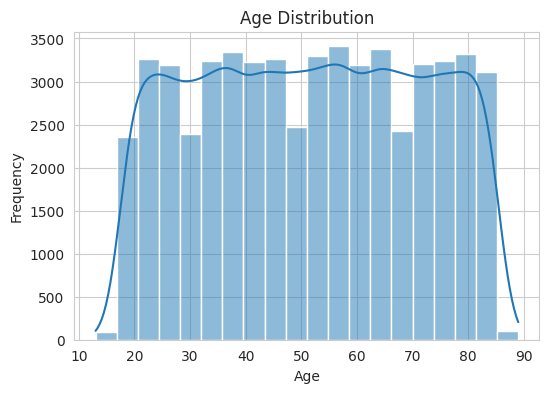

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

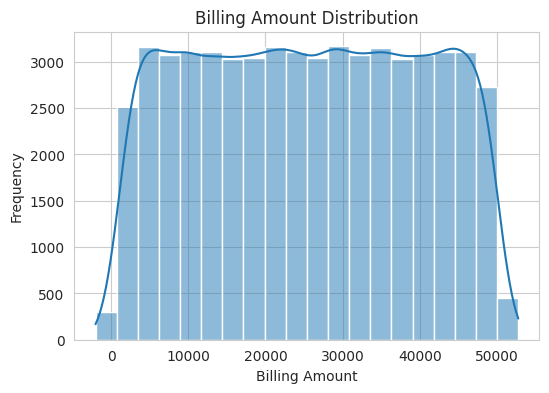

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df['Billing Amount'], bins=20, kde=True)
plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.ylabel("Frequency")
plt.show()

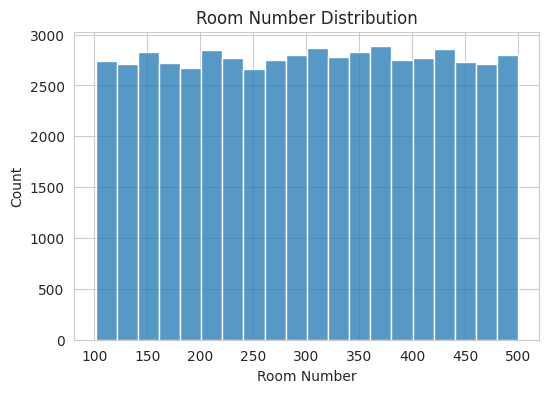

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Room Number'], bins=20)
plt.title("Room Number Distribution")
plt.xlabel("Room Number")
plt.ylabel("Count")
plt.show()

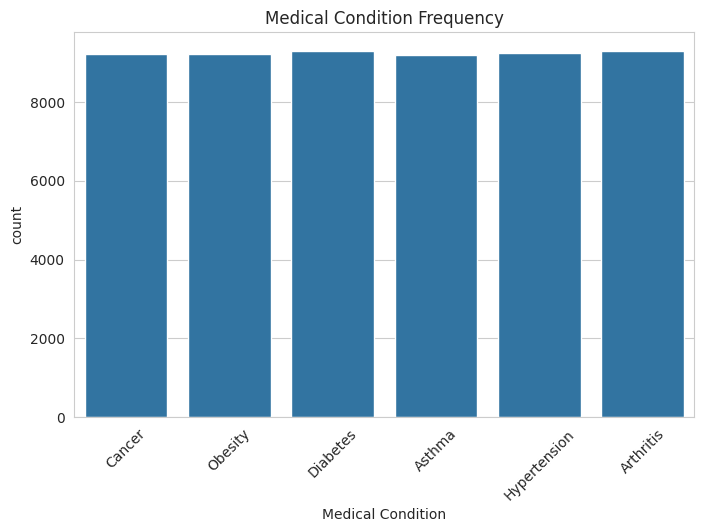

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Medical Condition', data=df)
plt.xticks(rotation=45)
plt.title("Medical Condition Frequency")
plt.show()

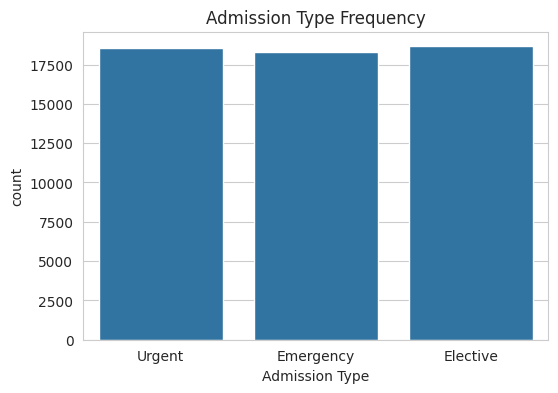

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Admission Type', data=df)
plt.title("Admission Type Frequency")
plt.show()

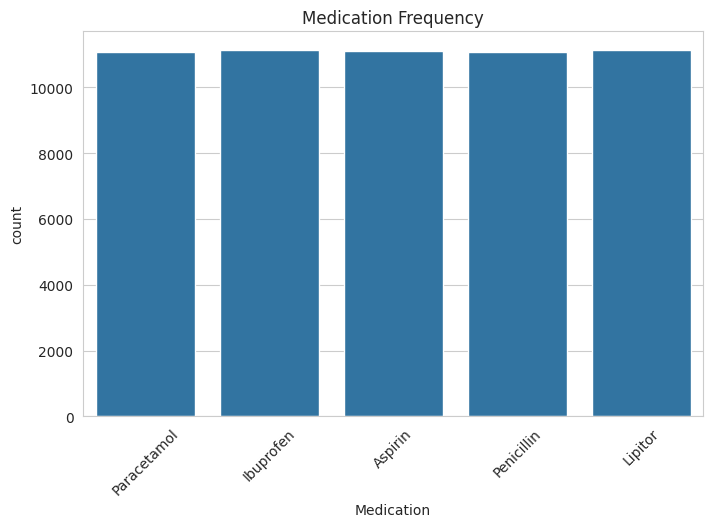

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Medication', data=df)
plt.xticks(rotation=45)
plt.title("Medication Frequency")
plt.show()

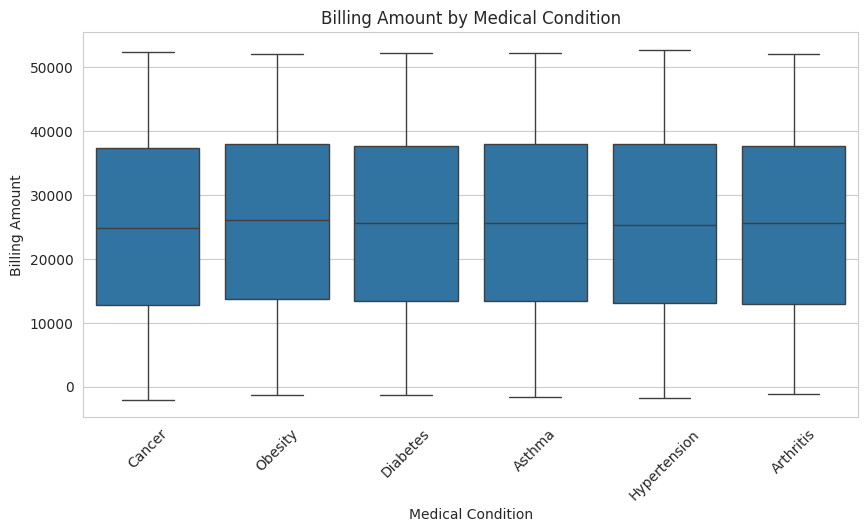

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Medical Condition', y='Billing Amount', data=df)
plt.xticks(rotation=45)
plt.title("Billing Amount by Medical Condition")
plt.show()

In [ ]:
#TASK 2

In [ ]:
# PREPARING DATASET

In [17]:
df_ml = df.copy()

df_ml = df_ml.drop(['Name', 'Doctor', 'Hospital'], axis=1)

In [18]:
df_ml['Stay Duration'] = (df_ml['Discharge Date'] - df_ml['Date of Admission']).dt.days

df_ml = df_ml.drop(['Date of Admission', 'Discharge Date'], axis=1)

In [19]:
df_ml = pd.get_dummies(df_ml, drop_first=True)

In [20]:
print(df['Test Results'].unique())

['Normal' 'Inconclusive' 'Abnormal']


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_ml['Test Results'] = le.fit_transform(df['Test Results'])

In [ ]:
# SPLIT OF DATASET

In [22]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Test Results', axis=1)
y = df_ml['Test Results']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# TRAINING OF THE MODEL

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# PREDICTIONS

In [24]:
y_pred = model.predict(X_test)

In [ ]:
#EVALUATIONS

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3754
           1       1.00      1.00      1.00      3617
           2       1.00      1.00      1.00      3729

    accuracy                           1.00     11100
   macro avg       1.00      1.00      1.00     11100
weighted avg       1.00      1.00      1.00     11100


Confusion Matrix:
 [[3754    0    0]
 [   0 3617    0]
 [   0    0 3729]]


In [26]:
# PREDICTED VS ACTUAL

In [27]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,0,0
6,1,1
7,0,0
8,1,1
9,2,2


In [28]:
results['Actual'] = le.inverse_transform(results['Actual'])
results['Predicted'] = le.inverse_transform(results['Predicted'])

In [29]:
#TASK 3

In [30]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Billing Amount']))

threshold = 3

df['Anomaly'] = z_scores > threshold
anomalies = df[df['Anomaly'] == True]

anomalies.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Anomaly


In [31]:
print("Total anomalies detected:", anomalies.shape[0])

Total anomalies detected: 0


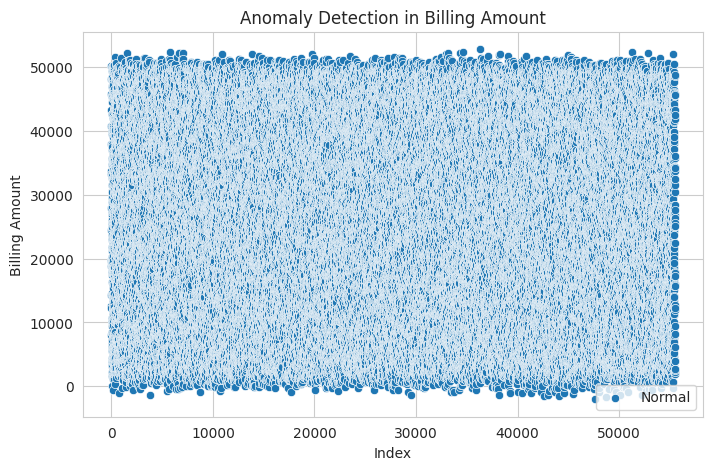

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=range(len(df)), y=df['Billing Amount'], label='Normal')

sns.scatterplot(
    x=anomalies.index,
    y=anomalies['Billing Amount'],
    color='red',
    label='Anomalies'
)

plt.title("Anomaly Detection in Billing Amount")
plt.xlabel("Index")
plt.ylabel("Billing Amount")
plt.legend()
plt.show()

In [33]:
anomalies[['Age', 'Medical Condition', 'Billing Amount']].head(10)

,Age,Medical Condition,Billing Amount


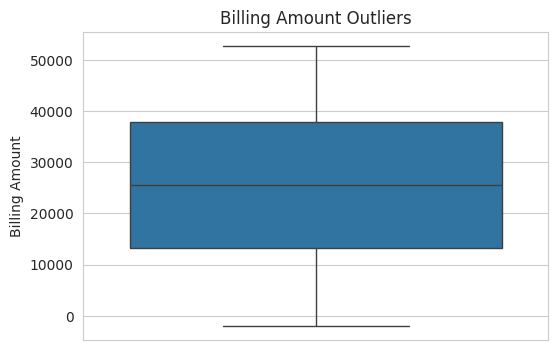

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Billing Amount'])
plt.title("Billing Amount Outliers")
plt.show()

In [35]:
#TASK 4

In [36]:
def generate_recommendation(age, condition, medication, result):

    if result.lower() == "positive":
        advice = "The condition appears to require immediate medical attention and close monitoring."
    else:
        advice = "The condition seems stable, but regular monitoring is advised."

    recommendation = f"""
    🩺 AI Doctor Recommendation

    Patient Summary:
    - Age: {age}
    - Medical Condition: {condition}
    - Medication: {medication}
    - Test Result: {result}

    Recommendation:
    {advice}
    Continue prescribed medication and maintain a healthy lifestyle.
    Ensure proper diet, hydration, and adequate rest.
    Follow up with your healthcare provider if symptoms persist or worsen.

    """

    return recommendation

In [37]:
sample_index = 0

age = df.iloc[sample_index]['Age']
condition = df.iloc[sample_index]['Medical Condition']
medication = df.iloc[sample_index]['Medication']

predicted_result = le.inverse_transform([y_pred[sample_index]])[0]

print(generate_recommendation(age, condition, medication, predicted_result))


    🩺 AI Doctor Recommendation

    Patient Summary:
    - Age: 30
    - Medical Condition: Cancer
    - Medication: Paracetamol
    - Test Result: Inconclusive

    Recommendation:
    The condition seems stable, but regular monitoring is advised.
    Continue prescribed medication and maintain a healthy lifestyle.
    Ensure proper diet, hydration, and adequate rest.
    Follow up with your healthcare provider if symptoms persist or worsen.

    


In [41]:
def generate_recommendation(age, condition, medication, result):

    if result.lower() == "positive":
        advice = "The condition appears to require immediate medical attention and close monitoring."
    else:
        advice = "The condition seems stable, but regular monitoring is advised."

    if condition.lower() == "diabetes":
        extra = "Monitor blood sugar levels regularly and avoid high sugar intake."
    elif condition.lower() == "hypertension":
        extra = "Reduce salt intake and manage stress levels."
    else:
        extra = "Maintain general health precautions."

    recommendation = f"""
🩺 AI Doctor Recommendation

Patient Summary:
- Age: {age}
- Medical Condition: {condition}
- Medication: {medication}
- Test Result: {result}

Recommendation:
{advice}

Additional Advice:
{extra}

General Instructions:
Continue prescribed medication, maintain proper diet, hydration, and regular follow-ups.
"""

    return recommendation